# Practical 7: Cell-Cell Communication

Author: Francesca Drummer, Claudio Novella-Rausell

In this notebook we will revocer cell-cell communication (CCC) in spatial transcriptomics. We will test different ways doing so:
    1. Non-spatial CCC testing
    2. Spatially DE genes
    3. Spatially-informed CC

In [1]:
import scanpy as sc
import squidpy as sq 
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import issparse, csr_matrix
import matplotlib.pyplot as plt
%matplotlib inline 
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

/opt/conda/envs/p6_ccc/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/conda/envs/p6_ccc/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


## 0. Download data

We will use the **Xenium AD dataset** from the previous notebooks here.

As a reminder the dataset consists of 6 coronal mouse brain slices from 2 different conditions (wildtype - ctrl vs TgCRND8 - AD) across 3 timepoints. In this practical, we additionally have information about cell types available in  `adata.obs['cell_types']`. Please note that these annotation are not perfect. For example, there are quite some cells that could not be assigned to a cell type (NaN or "unkown"). 

In this practical we aim to understand the differences of the mouse brain between the two conditions and across the timepoints using niches and spatial domains.

In [2]:
PATH = "data"

In [3]:
# load adata
#adata = sc.read_h5ad(Path(PATH, 'xenium_mouse_ad_annotated_rotated_v2.h5ad'))
adata = sc.read_h5ad(Path(PATH, 'xenium_mouse_ad_annotated_rotated_domain.h5ad'))
adata

AnnData object with n_obs × n_vars = 349725 × 347
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'condition', 'time', 'batch_key', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'cell_types', 'sample', 'n_counts', '_scvi_batch', '_scvi_labels', 'spatial_domain_temp'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cell_types_colors', 'dea_leiden_res0_25', 'dendrogram_leiden_res0_25', 'leiden', 'leiden_res0_25_colors', 'leiden_res0_5_colors', 'leiden_res1_colors', 'neighbors', 'sample_colors', 'spatial_domain_temp_colors', 'spatial_neighbors', 'umap'
    obsm: 'X_cellcharter_temp', 'X_pca', 'X_scVI', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [4]:
# load spatial domains from previous practical
#adata.obs["spatial_domain_temp"] = pd.read_csv(Path(PATH, 'spatial_domains.csv'), index_col=0).astype(str)
#adata = adata[~adata.obs["spatial_domain_temp"].isna()].copy() # let's filter out cells to match practical 6. These were probably filtered out prior to scVI

# do not have the file! 

FileNotFoundError: [Errno 2] No such file or directory: 'data/spatial_domains.csv'

In [6]:
print(adata.obs[['cell_id']].head())
print(adata.obs[['cell_labels']].value_counts())
print(adata.obs[['condition']].value_counts())
print(adata.obs[['time']].value_counts())
print(adata.obs[['batch_key']].value_counts())
print(adata.obs[['cell_types']].value_counts())
print(adata.obs[['sample']].value_counts())

        cell_id
0-0  aaabfoap-1
1-0  aaabonpk-1
2-0  aaadnjke-1
3-0  aaaeilha-1
4-0  aaaenhoh-1
cell_labels
1              6
35520          6
35510          6
35511          6
35512          6
              ..
60643          1
60642          1
60641          1
60640          1
62268          1
Name: count, Length: 62077, dtype: int64
condition
wildtype     176597
TgCRND8      173128
Name: count, dtype: int64
time
5_7     117335
2_5     112096
17_9     60593
13_4     59701
Name: count, dtype: int64
batch_key
2            60593
5            59701
4            58671
1            58664
3            58225
0            53871
Name: count, dtype: int64
cell_types        
Excitatory neurons    85878
Astrocytes            73625
Unknown               65516
Oligodendrocytes      64086
Inhibitory neurons    44539
Microglia             10988
OPC                    5093
Name: count, dtype: int64
sample       
TgCRND8_17_9     60593
wildtype_13_4    59701
wildtype_5_7     58671
TgCRND8_5_7      58664


In [7]:
adata.obs.groupby('time')['condition'].value_counts()

/tmp/ipykernel_8005/2760430911.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


time  condition
2_5   wildtype     58225
      TgCRND8      53871
5_7   wildtype     58671
      TgCRND8      58664
13_4  wildtype     59701
      TgCRND8          0
17_9  TgCRND8      60593
      wildtype         0
Name: count, dtype: int64

In [8]:
print(adata.X[:10,:10])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 10 stored elements and shape (10, 10)>
  Coords	Values
  (1, 0)	1.0
  (2, 8)	1.0
  (3, 8)	1.0
  (4, 2)	1.0
  (4, 3)	3.0
  (8, 4)	1.0
  (8, 8)	1.0
  (9, 1)	1.0
  (9, 3)	2.0
  (9, 8)	1.0


In [9]:
adata.layers['counts'] = adata.X

In [10]:
# Normalization to the median
sc.pp.normalize_total(adata)

# Freeman-Tukey square root transform
assert issparse(adata.X)
sqrt_X = adata.X.sqrt()
# Create a new sparse matrix for X + 1
X_plus_1 = adata.X + csr_matrix(np.ones(adata.X.shape))
# Calculate the square root of (X + 1)
sqrt_X_plus_1 = X_plus_1.sqrt()
adata.layers['median_ft'] = sqrt_X + sqrt_X_plus_1

## 0. Introduction to LIANA+

[LIANA+](https://liana-py.readthedocs.io/en/latest/notebooks/basic_usage.html) is a toolbox in Python for various dissociated, multimodal and spatially informed cell-cell communication tools [Dimitrov et al., 2024]. 

First we install the package and observe which methods are implemented in LIANA+. 
Each method relies on different assumptions and returns a different ligand-receptor score. 
Usually, one score for the strength of the interaction (`magnitude`) and a score reflecting the `specifivity` of a interaction to a pair of cell identities. 

In [11]:
import liana as li

li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


Most CCC tools identify LR interaction. For this they rely on a extracting LR pairs from databases. There are diverse databases but LIANA+ has a consensus database that uses LR that are overlapping across databases. 

First, we need to ensure that there are LR-pairs present in the data to be detected for communication.

In [12]:
print(li.resource.show_resources())
resource_name = "mouseconsensus"  # Replace with the desired resource name if needed
lr_pairs = li.resource.select_resource(resource_name)
lr_pairs

['baccin2019', 'cellcall', 'cellchatdb', 'cellinker', 'cellphonedb', 'celltalkdb', 'connectomedb2020', 'consensus', 'embrace', 'guide2pharma', 'hpmr', 'icellnet', 'italk', 'kirouac2010', 'lrdb', 'mouseconsensus', 'ramilowski2015']


,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3
...,...,...
35355,Serpina1a,Lrp1
35356,Serpina1b,Lrp1
35357,Serpina1c,Lrp1
35358,Serpina1d,Lrp1


In [13]:
def lr_pairs_in_adata(adata):
    genes_in_dataset = set(adata.var_names)  # Replace `adata.var_names` with your dataset's gene names if different
    
    # Filter the ligand-receptor pairs for those present in your dataset
    filtered_lr_pairs = lr_pairs[
        lr_pairs['ligand'].isin(genes_in_dataset) & lr_pairs['receptor'].isin(genes_in_dataset)
    ]
    
    return filtered_lr_pairs
    

In [14]:
filtered_lr_pairs = lr_pairs_in_adata(adata)

<span style="color:red; font-weight:bold">Task 1: How many ligand-receptor pairs are in the data?</span>

<details>
<summary>💡 Show solution</summary>
    
```python
# Count the number of ligand-receptor pairs present in your dataset
num_lr_pairs = len(filtered_lr_pairs)

# Display the count
print(f"Number of ligand-receptor pairs present in the dataset: {num_lr_pairs}")
```

In [15]:
num_lr_pairs = len(filtered_lr_pairs)
print(f"Number of ligand-receptor pairs present in the dataset: {num_lr_pairs}")


Number of ligand-receptor pairs present in the dataset: 16


In the following chapter, we will work with the CellPhoneDB method from LIANA+.

## 1. CellPhoneDB: non-spatial CCC

First, we will run CellPhoneDB as if we did not have any spatial information. 

In [16]:
sub_adata = adata[(adata.obs['time'] == '5_7') & (adata.obs['condition'] == 'TgCRND8')]
sub_adata

View of AnnData object with n_obs × n_vars = 58664 × 347
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'condition', 'time', 'batch_key', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'cell_types', 'sample', 'n_counts', '_scvi_batch', '_scvi_labels', 'spatial_domain_temp'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cell_types_colors', 'dea_leiden_res0_25', 'dendrogram_leiden_res0_25', 'leiden', 'leiden_res0_25_colors', 'leiden_res0_5_colors', 'leiden_res1_colors', 'neighbors', 'sample_colors', 'spatial_domain_temp_colors', 'spatial_neighbors', 'umap'
    obsm: 'X_cellcharter_temp', 'X_pca', 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'median_ft'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [17]:
cellphonedb(sub_adata,
            groupby='cell_types',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            use_raw = False,
            layer = 'counts',
            key_added='cpdb_res')

Using resource `mouseconsensus`.
Using the `counts` layer!
/opt/conda/envs/p6_ccc/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/conda/envs/p6_ccc/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 58664 samples and 22 features


100%|██████████| 1000/1000 [00:05<00:00, 186.30it/s]
/opt/conda/envs/p6_ccc/lib/python3.11/site-packages/liana/method/sc/_Method.py:266: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [20]:
#print(sub_adata.uns)

In [21]:
sub_adata.uns['cpdb_res'].head(10)
#sub_adata.uns['cpdb_res'].loc[(sub_adata.uns['cpdb_res']['ligand'] == 'C1qa') &
#                             (sub_adata.uns['cpdb_res']['receptor'] == 'Cd93')]

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
22,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,2.806489,0.830238,Astrocytes,Excitatory neurons,8.199455,0.0
52,Apoe,Apoe,13.592422,0.999126,Trem2,Trem2,1.608136,0.666484,Astrocytes,Microglia,7.600279,0.0
37,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,1.550732,0.761789,Astrocytes,Inhibitory neurons,7.571578,0.0
0,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,0.938511,0.528414,Astrocytes,Astrocytes,7.265467,0.0
97,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,0.901477,0.405407,Astrocytes,Unknown,7.246950,0.0
74,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,0.722670,0.390274,Astrocytes,OPC,7.157546,0.0
53,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,0.652417,0.351558,Astrocytes,Microglia,7.122419,0.0
89,Apoe,Apoe,13.592422,0.999126,Sorl1,Sorl1,0.611004,0.315366,Astrocytes,Oligodendrocytes,7.101713,0.0
31,Apoe,Apoe,8.985492,0.983791,Sorl1,Sorl1,2.806489,0.830238,OPC,Excitatory neurons,5.895990,0.0
65,Apoe,Apoe,8.985492,0.983791,Trem2,Trem2,1.608136,0.666484,OPC,Microglia,5.296813,0.0


<div style="border: 1px solid #0000ff; padding: 10px; border-radius: 5px;">
<span style="color: #0000ff; font-size: 20px;"><b>Interpretation</b></span> <span style="font-size: 20px;">Liana+ scores</span>  

<span></span>
<ul>
    <li>source and target columns represent the source/sender and target/receiver cell identity for each interaction, respectively</li>
    <li>*_props: represents the proportion of cells that express the entity.</li>
    <li>*_means: entity expression mean per cell type.</li>
    <li>lr_means: mean ligand-receptor expression, as a measure of ligand-receptor interaction magnitude</li>
</ul>

<span style="color:red; font-weight:bold">Task 2: Plot the top 3 interacting complexes</span>

<details>
<summary>💡 Show solution</summary>
    
```python
sq.pl.spatial_scatter(sub_adata, 
                      color=[],
                      layer = 'median_ft',
                      shape=None)
```

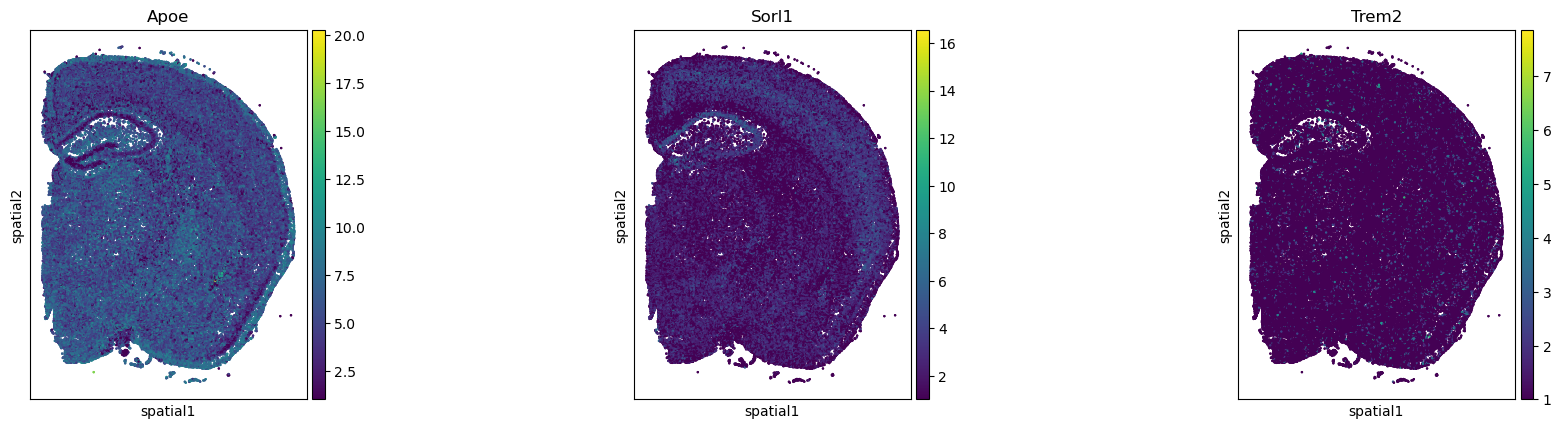

In [31]:
sq.pl.spatial_scatter(sub_adata, 
                      color=['Apoe','Sorl1','Trem2'],
                      layer = 'median_ft',
                      shape=None)

In [34]:
adata.obs['cell_types'].value_counts()

cell_types
Excitatory neurons    85878
Astrocytes            73625
Unknown               65516
Oligodendrocytes      64086
Inhibitory neurons    44539
Microglia             10988
OPC                    5093
Name: count, dtype: int64

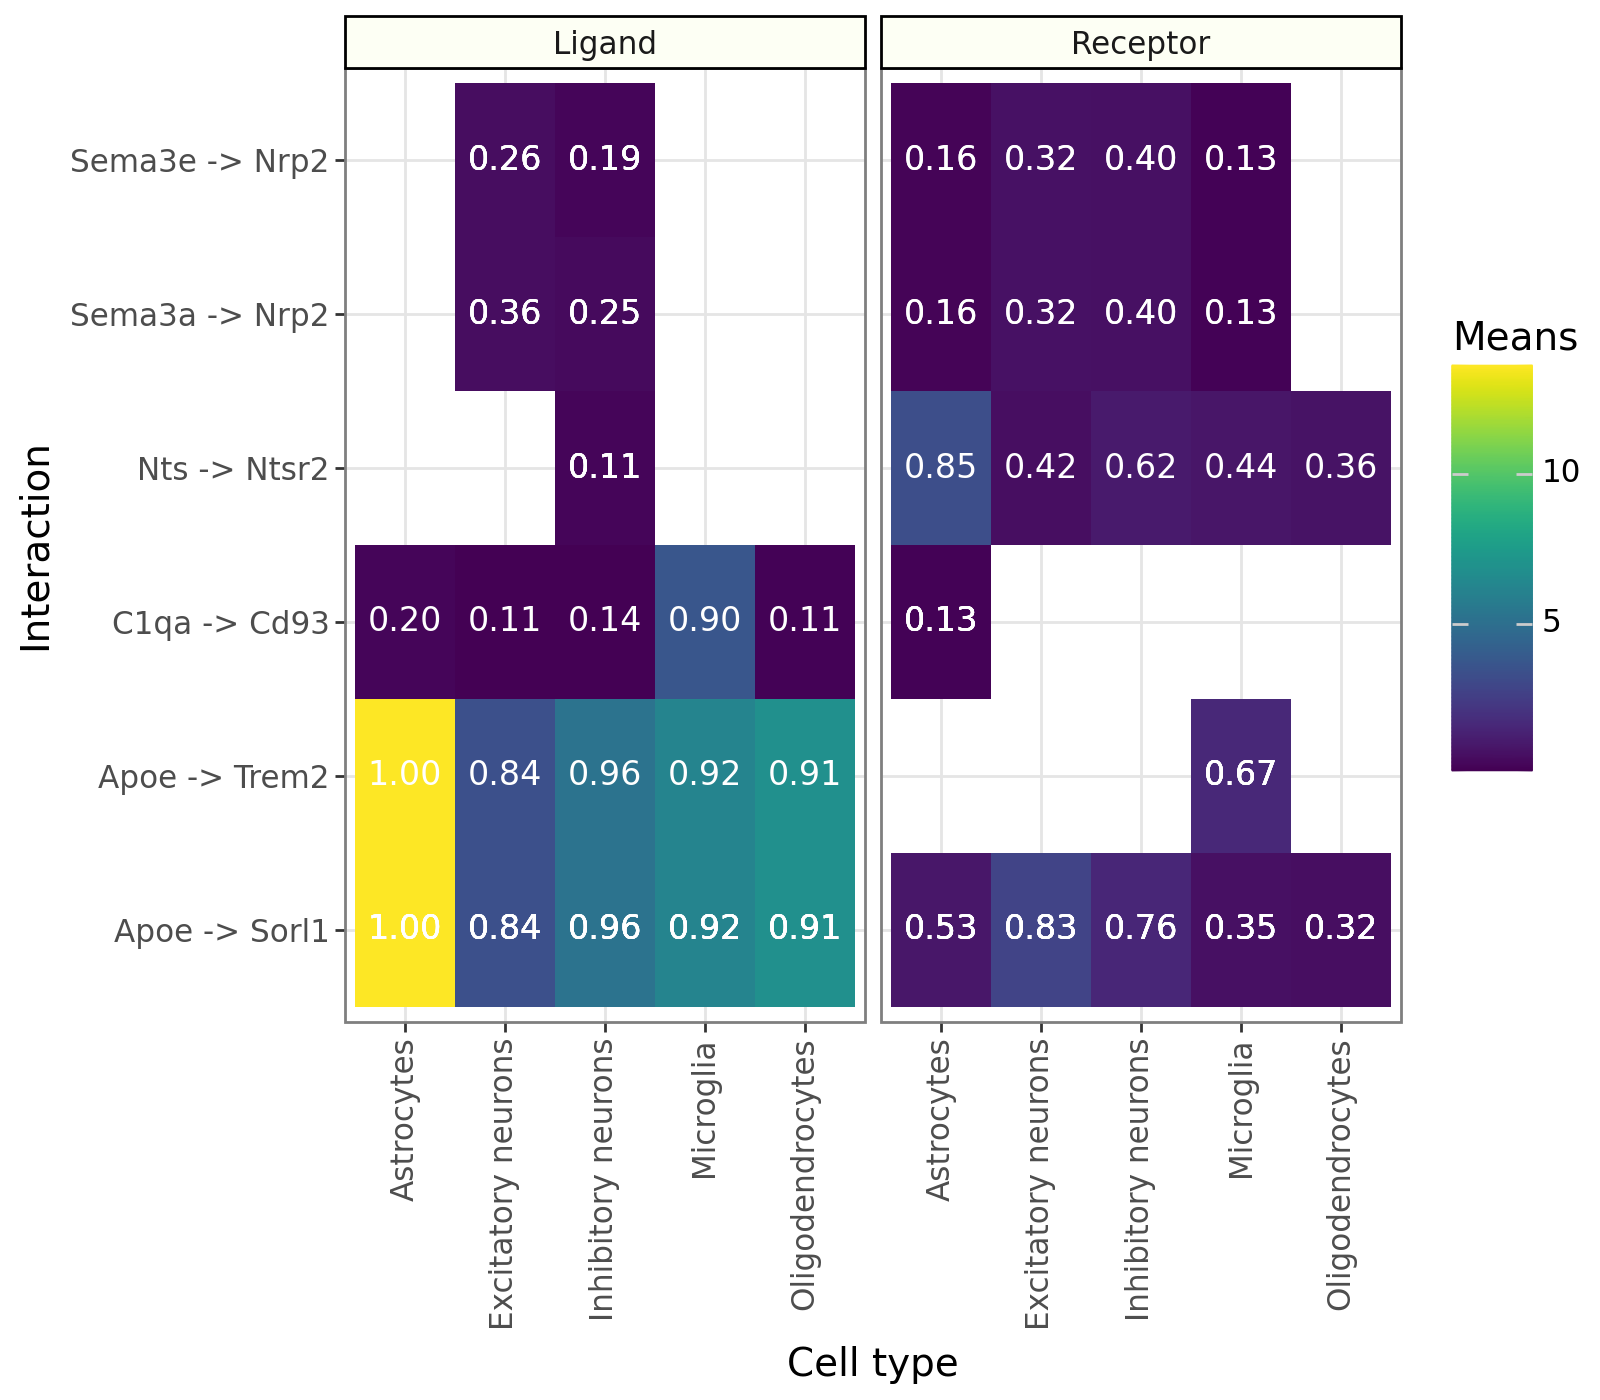

In [35]:
my_plot = li.pl.tileplot(adata = sub_adata,
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=30,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['Astrocytes', 'Oligodendrocytes', 'Microglia',  'Inhibitory neurons', 'Excitatory neurons'],
                         target_labels=['Astrocytes', 'Oligodendrocytes', 'Microglia',  'Inhibitory neurons', 'Excitatory neurons'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )

# 'Mixed Neurons/Oligo' not in object
my_plot

<span style="color:red; font-weight:bold">Question: What can we observe if we do not consider spatial information? Why could this be problematic?</span>

To overcome this issue we will cover two possible approaches to integrate spatial information into non-spatially aware CCC tools, like `CellPhoneDB`.

1. Restrict the input to spatially variable genes. 
2. Post-processing of interactions using spatial proximity, i.e. niche information. 

### Spatially-variable gene selection

We use Moran's I score as a measure of spatial autocorrelation to identify spatially variable genes. 

For more information see: [Chapter 29: Spatially variable genes](https://www.sc-best-practices.org/spatial/spatially_variable_genes.html) from single-cell best practices.

1. Calculate a spatial graph (`sq.gr.spatial_neighbors`)
2. Calculate autocorrelation with [Morans I score](https://squidpy.readthedocs.io/en/stable/notebooks/examples/graph/compute_moran.html) (`sq.gr.spatial_autocorr`)

In [ ]:
print(sub_adata.X[:5,:5])

In [ ]:
sq.gr.spatial_neighbors(sub_adata, n_neighs=30, coord_type="generic", key_added = 'neighs_based_spatial')

In [ ]:
sq.gr.interaction_matrix(sub_adata, cluster_key='celltype', connectivity_key = 'neighs_based_spatial', normalized=True)

In [ ]:
sq.pl.interaction_matrix(sub_adata, cluster_key='celltype')

In [ ]:
sq.gr.spatial_autocorr(sub_adata, connectivity_key = "neighs_based_spatial_connectivities", mode="moran", n_perms=50, genes=sub_adata.var_names)

Show and plot the top genes according to Moran's I score autocorrelation.

In [ ]:
sub_adata.uns["moranI"].head()

<div style="border: 1px solid #0000ff; padding: 10px; border-radius: 5px;">
<span style="color: #0000ff; font-size: 20px;"><b>Moran's I score</b></span> <span style="font-size: 20px;"></span>  

<span></span>
<ul>
    <li>I so the Moran’s I,</li>
    <li>pval_norm a p-value under normality assumption.</li>
    <li>var_norm the variance of the Moran’s I under normality assumption.</li>
    <li>{p_val}_{corr_method} the corrected p-values.</li>
</ul>

<span style="color:red; font-weight:bold">Task 3: Plot the 3 genes with the highest I score.</span>

<details>
<summary>💡 Show solution</summary>
    
```python
sq.pl.spatial_scatter(sub_adata, 
                      color=[],
                      layer = 'median_ft',
                      shape=None)
```

<span style="color:red; font-weight:bold">Task 4: Subset the data to include only genes that have a Morans I score higher than 0,2 and check that there are still relevant ligand-receptor pairs in the subdata.</span>

<details>
<summary>💡 Show solution</summary>
    
```python
sub_adata_svg = sub_adata[:, sub_adata.uns["moranI"]['I'] > 0.2]
sub_adata_svg
lr_pairs_in_adata(sub_adata_svg)
```

#### CellPhoneDB

In [ ]:
cellphonedb(sub_adata_svg,
            groupby='celltype',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            use_raw = False,
            layer = 'counts',
            key_added='cpdb_res')

In [ ]:
sub_adata_svg.uns['cpdb_res']

In [ ]:
my_plot = li.pl.tileplot(adata = sub_adata_svg,
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=20,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['Astrocytes', 'Oligodendrocytes', 'Microglia', 'Mixed Neurons/Oligo', 'Inhibitory neurons', 'Excitatory neurons'],
                         target_labels=['Astrocytes'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

<span style="color:red; font-weight:bold">Question: What could be a potential limitation / problem with this approach?</span>

<span style="color:red; font-weight:bold">Optional Task: Compare the results for the healthy control or different time points. Do the CCC across cell types change?.</span>

<span style="color:red; font-weight:bold">Optional Task: Change the `expr_prop` in the CellPhoneDB function and try out some other tools like CellChat. How does it effect the results?.</span>

### Spatial proximity

An alternative to pre-selecting spatially variable genes is by restricting the cells to be spatially close when they are communicating. For this we will be using the calculated spatial domains from the previous tutorial. 

In [ ]:
sq.pl.spatial_scatter(sub_adata,
                      color = ['celltype', 'spatial_domain_temp'],
                      shape=None)

<span style="color:red; font-weight:bold">Task 5: Choose a spatial domain cluster that contains a high proportion of the cell types you are interested in to understand the interaction. Tip: also check that the fraction of unknown cells is low. </span>

In [ ]:
def relative_abundances(adata, group_by, cell_type_key):
    counts = adata.obs.groupby([group_by, cell_type_key]).size().unstack(fill_value=0)
    relative_abundance = counts.div(counts.sum(axis=1), axis=0)
    return relative_abundance

In [ ]:
relative_abundances(sub_adata, group_by='spatial_domain_temp', cell_type_key='celltype')

In [ ]:
## TODO
domain = 

In [ ]:
sub_adata_domain = sub_adata[sub_adata.obs['spatial_domain_temp'] == domain]
sub_adata_domain

In [ ]:
cellphonedb(sub_adata_domain,
            groupby='celltype',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            use_raw = False,
            layer = 'counts',
            key_added='cpdb_res')

In [ ]:
sub_adata_domain.uns['cpdb_res'].head()

In [ ]:
my_plot = li.pl.tileplot(adata = sub_adata_domain,
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=20,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['Astrocytes', 'Microglia',  'Oligodendrocytes'],
                         target_labels=['Astrocytes', 'Microglia', 'Oligodendrocytes'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot